# 4. How Does Runtime Vary by Content Rating?

**Question:** How well do jobs and skills "pay" for Data Analysts? — adapted here to: how does movie *runtime* (a proxy for production scale/investment) vary by content rating?

This mirrors the reference project's salary-distribution analysis, swapping salary for runtime as the numeric variable of interest.

## Import & Clean Up Data

I isolate Movies (TV Shows report seasons, not minutes, in the same `duration` field) and extract the numeric minute value.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('netflix_titles.csv')
movies = df[df['type'] == 'Movie'].copy()
movies['duration_min'] = movies['duration'].str.extract(r'(\d+)').astype(float)

movies['duration_min'].describe()

## Visualize Data

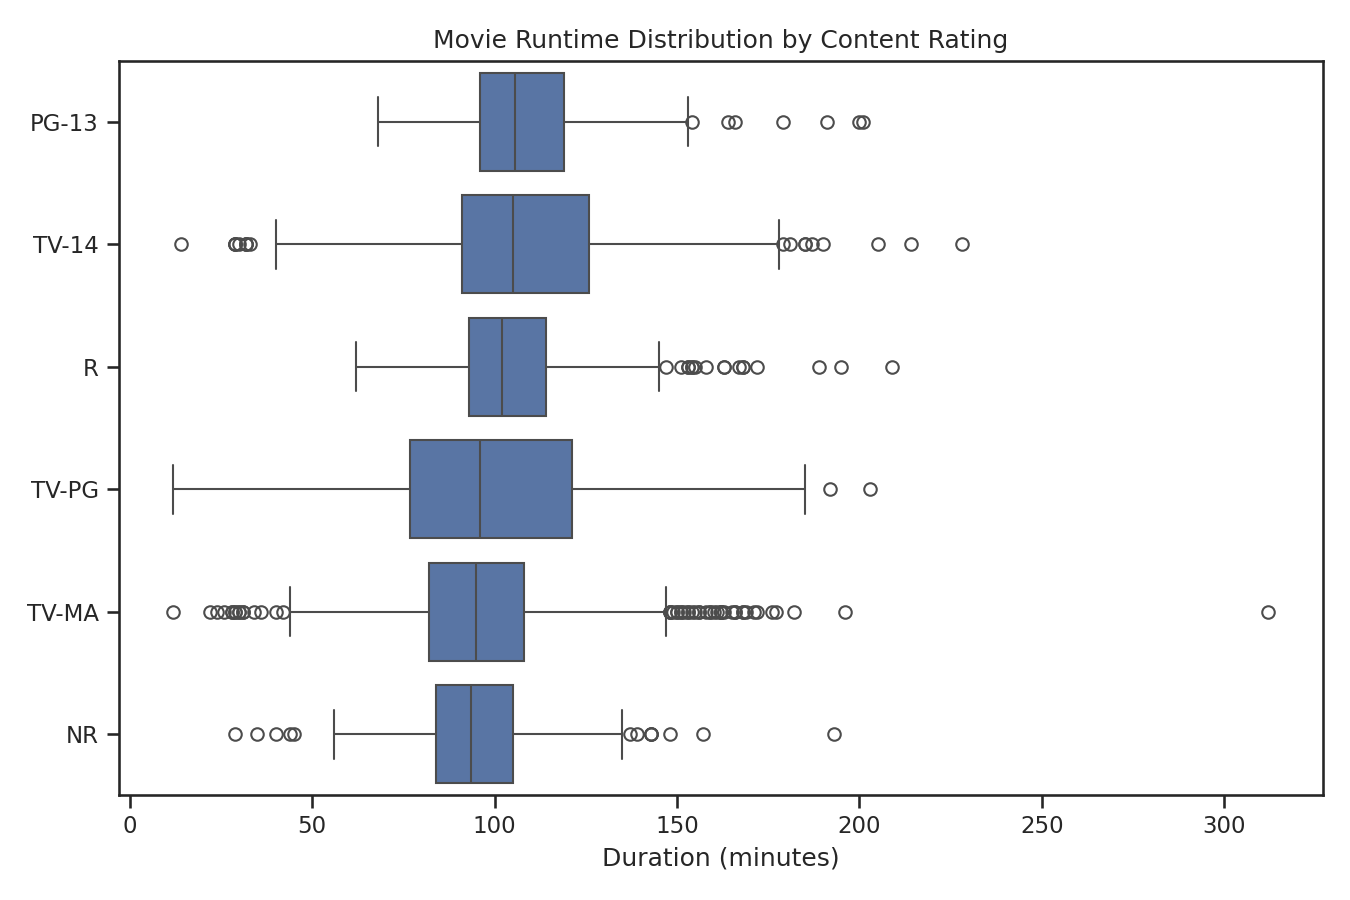

In [1]:
top_ratings = movies['rating'].value_counts().head(6).index.tolist()
order = (
    movies[movies['rating'].isin(top_ratings)]
    .groupby('rating')['duration_min']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(9, 6))
sns.boxplot(data=movies[movies['rating'].isin(top_ratings)], x='duration_min', y='rating', order=order, ax=ax)
ax.set_title('Movie Runtime Distribution by Content Rating')
ax.set_xlabel('Duration (minutes)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

### Insights

- **PG-13** and **TV-14** movies have the longest median runtimes (around 105 minutes), consistent with these ratings covering mainstream action, drama, and blockbuster-style films built for a full theatrical or prestige-TV runtime.
- **TV-MA** and **NR (Not Rated)** movies run noticeably shorter on average — TV-MA often includes stand-up comedy specials and edgier independent films, which tend to be tighter productions.
- The spread (box width) is fairly similar across ratings, meaning runtime variability isn't strongly tied to content rating — rating mainly shifts the *typical* runtime, not the *range* of runtimes.